<a href="https://colab.research.google.com/github/KimJongBin01/session-based-IDS-Contrastive-Learning-/blob/main/session_based_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<Eclog(정상 트래픽)>**

실제 폴란드 온라인 쇼핑몰의 nginx 서버 엑세스 로그
하루치 데이터 -> 35만건의 HTTP 요청
IP,UA, timestamp, method, status, bytes, referrer 필드를 갖음

**<CSIC 2010(공격 트래픽)>**

스페인 국립연구회가 자동 생성한 e-commerce 웹/앱 HTTP 트래픽
정상요청 36000건, 공격 25000건
공격 유형은 SQLi, XSS, Buffer overflow, CRLFi 등 다양함

**<대조 학습을 위한 데이터 전처리>**

**1. EClog** (정상 데이터)

봇 필터링(자동으로 요청한 건)

정상 데이터 2024개 (IP) 선별 -> 세션분리 IpId 기준 30분 타임아웃, 선별 후 세션화 메서드 적용


**2. Positive pair**

정상 요청에 Dropout + Jitter 증강


**3. Negative pair**

정상 요청 + CISC 공격 요청 (공격이 섞인 세션)


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!ls -lh /content/drive/MyDrive/csic2010/

total 294M
-rw------- 1 root root 16M May 11 07:10 anomalousTrafficTest.txt
-rw------- 1 root root 20M May 14 13:48 attack_requests.pkl
-rw------- 1 root root 94M May 11 06:11 eclog_1day.csv
-rw------- 1 root root 36M May 14 15:59 negative_pairs.pkl
-rw------- 1 root root 20M May 11 07:10 normalTrafficTest.txt
-rw------- 1 root root 20M May 11 07:10 normalTrafficTraining.txt
-rw------- 1 root root   0 May 16 04:22 positive_pairs.pkl
-rw------- 1 root root 35M May 14 15:59 sessions.pkl
-rw------- 1 root root 58M May 11 07:24 web_logs.pkl


In [17]:
import os
from google.colab import files
import pandas as pd
import random
import matplotlib.pyplot as plt
import pickle

In [18]:
DRIVE_PATH = "/content/drive/MyDrive/csic2010"
os.makedirs(DRIVE_PATH, exist_ok=True)

# 드라이브에 없을 때만 다운로드
files = {
    "normalTrafficTraining.txt": f"{DRIVE_PATH}/normalTrafficTraining.txt",
    "anomalousTrafficTest.txt":  f"{DRIVE_PATH}/anomalousTrafficTest.txt",
    "normalTrafficTest.txt":     f"{DRIVE_PATH}/normalTrafficTest.txt",
}

BASE_URL = "https://raw.githubusercontent.com/msudol/Web-Application-Attack-Datasets/master/OriginalDataSets/csic_2010"

for filename, filepath in files.items():
    if not os.path.exists(filepath):
        print(f"다운로드 중: {filename}")
        os.system(f'wget -q "{BASE_URL}/{filename}" -O "{filepath}"')
    else:
        print(f"이미 있음: {filename}")

print("완료!")

이미 있음: normalTrafficTraining.txt
이미 있음: anomalousTrafficTest.txt
이미 있음: normalTrafficTest.txt
완료!


In [19]:
# 드라이브에서 로드

normal_train_path = f"{DRIVE_PATH}/normalTrafficTraining.txt"
anomalous_path    = f"{DRIVE_PATH}/anomalousTrafficTest.txt"
normal_test_path  = f"{DRIVE_PATH}/normalTrafficTest.txt"


In [20]:
# 처음 50줄 확인
with open(DRIVE_PATH+"/normalTrafficTraining.txt", "r", encoding="latin-1") as f:
    for i, line in enumerate(f):
        print(line, end="")
        if i > 50:
            break

GET http://localhost:8080/tienda1/index.jsp HTTP/1.1
User-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)
Pragma: no-cache
Cache-control: no-cache
Accept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5
Accept-Encoding: x-gzip, x-deflate, gzip, deflate
Accept-Charset: utf-8, utf-8;q=0.5, *;q=0.5
Accept-Language: en
Host: localhost:8080
Cookie: JSESSIONID=1F767F17239C9B670A39E9B10C3825F4
Connection: close


GET http://localhost:8080/tienda1/publico/anadir.jsp?id=3&nombre=Vino+Rioja&precio=100&cantidad=55&B1=A%F1adir+al+carrito HTTP/1.1
User-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)
Pragma: no-cache
Cache-control: no-cache
Accept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5
Accept-Encoding: x-gzip, x-deflate, gzip, deflate
Accept-Charset: utf-8, utf-8;q=0.5, *;q=0.5
Accept-Language: en
Host: localhost:8080
Cookie: 

**EClog**

정상데이터 확인

In [21]:
# Eclog 데이터셋 로드
df = pd.read_csv("/content/drive/MyDrive/csic2010/eclog_1day.csv")

# web_logs 로드
with open("/content/drive/MyDrive/csic2010/web_logs.pkl", "rb") as f:
    web_logs = pickle.load(f)

print(f"EClog 로드 완료: {len(df):,}건")
print(f"web_logs 로드 완료: {len(web_logs):,}개")

EClog 로드 완료: 350,683건
web_logs 로드 완료: 2,248개


In [22]:
# Eclog 데이터 읽어들이기
df = pd.read_csv("/content/drive/MyDrive/csic2010/eclog_1day.csv", nrows=5)
print(f"컬럼: {df.columns.tolist()}")
print(f"\n=== 첫 5행 ===")
print(df.head())

컬럼: ['IpId', 'UserId', 'TimeStamp', 'HttpMethod', 'Uri', 'HttpVersion', 'ResponseCode', 'Bytes', 'Referrer', 'UserAgent']

=== 첫 5행 ===
  IpId UserId           TimeStamp HttpMethod                          Uri  \
0  1PL      -  637116156000000000       POST  /inne/informacja_online.php   
1  1PL      -  637116156010000000       POST  /inne/informacja_online.php   
2  2NL      -  637116156010000000        GET    /wyszukiwanie-query1.html   
3  3PL      -  637116156050000000       POST  /inne/informacja_online.php   
4  4PL      -  637116156050000000       POST  /inne/informacja_online.php   

  HttpVersion  ResponseCode  Bytes  \
0    HTTP/1.1           200      0   
1    HTTP/1.1           200      0   
2    HTTP/1.1           200   9018   
3    HTTP/1.1           200      0   
4    HTTP/1.1           200      0   

                                            Referrer  \
0   https://shop.our-internet-company.pl/p-5315.html   
1  https://shop.our-internet-company.pl/p-10152.html   
2   

In [23]:
# 전체 로드 + 기본 통계
df = pd.read_csv("/content/drive/MyDrive/csic2010/eclog_1day.csv")

print(f"총 요청 수: {len(df):,}")
print(f"\n=== ResponseCode 분포 ===")
print(df["ResponseCode"].value_counts().head(10))

print(f"\n=== HttpMethod 분포 ===")
print(df["HttpMethod"].value_counts())

print(f"\n=== 고유 IpId 수 ===")
print(f"{df['IpId'].nunique():,}명")

print(f"\n=== 고유 UserId 수 ===")
print(f"{df['UserId'].nunique():,}명")

총 요청 수: 350,683

=== ResponseCode 분포 ===
ResponseCode
200    338043
304      6847
301      3387
302      1471
499       388
404       307
206       150
403        72
400        11
408         7
Name: count, dtype: int64

=== HttpMethod 분포 ===
HttpMethod
GET     288556
POST     62075
HEAD        43
-            9
Name: count, dtype: int64

=== 고유 IpId 수 ===
4,297명

=== 고유 UserId 수 ===
1명


In [24]:
# 세션 분리 가능한지 확인
# IpId 기반으로 요청 묶어보기
sample_ip = df["IpId"].iloc[0]

# ip 하나 잡아서 요청 시간 순으로
ip_df = df[df["IpId"] == sample_ip].sort_values("TimeStamp")

print(f"IpId: {sample_ip}")
print(f"요청 수: {len(ip_df)}")
print(f"\n=== 흐름 ===")
print(ip_df[["IpId", "TimeStamp", "HttpMethod", "Uri", "ResponseCode"]].to_string())

IpId: 1PL
요청 수: 236

=== 흐름 ===
      IpId           TimeStamp HttpMethod                          Uri  ResponseCode
0      1PL  637116156000000000       POST  /inne/informacja_online.php           200
1      1PL  637116156010000000       POST  /inne/informacja_online.php           200
13     1PL  637116156100000000       POST  /inne/informacja_online.php           200
15     1PL  637116156130000000       POST  /inne/informacja_online.php           200
28     1PL  637116156250000000       POST  /inne/informacja_online.php           200
37     1PL  637116156310000000       POST  /inne/informacja_online.php           200
102    1PL  637116156420000000       POST  /inne/informacja_online.php           200
120    1PL  637116156600000000       POST  /inne/informacja_online.php           200
123    1PL  637116156630000000       POST  /inne/informacja_online.php           200
127    1PL  637116156650000000       POST  /inne/informacja_online.php           200
128    1PL  637116156660000000   

In [25]:
# URI 다양성 기준으로 정상 IP 필터링
# IP 기준으로 그룹핑 + 기본 통계
ip_stats = df.groupby("IpId").agg(
    total_requests=("Uri", "count"), # 총 요청 개수
    unique_uris=("Uri", "nunique"),  # 중복을 제외한 Uri 개수(방문항 페이지 종류)
    unique_methods=("HttpMethod", "nunique") # 중복 제외한 CRUD 메서드 종류
).reset_index() # 일반 컬럼으로 쓰기 위함

# URI 다양성 비율 계산 (실제 사용 URI 종류) / (전체 요청 개수)
ip_stats["uri_diversity"] = ip_stats["unique_uris"] / ip_stats["total_requests"]

print("=== IP별 통계 샘플 ===")
print(ip_stats.sort_values("total_requests", ascending=False).head(20))

=== IP별 통계 샘플 ===
        IpId  total_requests  unique_uris  unique_methods  uri_diversity
4241   950PL            6613         2394               2       0.362014
3850   599PL            6147         2716               2       0.441842
2843  3560PL            4870         2227               2       0.457290
3812   564PL            3601         1514               2       0.420439
1450  2306PL            3480         2509               2       0.720977
3349  4015PL            3292         1173               2       0.356318
310   1280PL            2667          368               2       0.137983
332     12US            2446         1835               2       0.750204
1875   268PL            2371         1940               2       0.818220
317   1287PL            2327         1883               2       0.809196
2953   365PL            2311         1814               2       0.784942
1456  2311PL            2297           53               2       0.023074
3098  3790PL            2222     

In [26]:
# 정상 사용자 필터링
# uri_diversity > 0.3, 요청 수 3~500개

# IpId만 뽑아냄
normal_ips = ip_stats[
    (ip_stats["uri_diversity"] > 0.3) &
    (ip_stats["total_requests"] >= 3) &
    (ip_stats["total_requests"] <= 500)
]["IpId"]

print(f"전체 IP 수: {len(ip_stats):,}")
print(f"정상 IP 수: {len(normal_ips):,}")

# 정상 IP의 요청만 필터링
normal_df = df[df["IpId"].isin(normal_ips)].copy()
print(f"\n정상 요청 수: {len(normal_df):,}")

# 샘플 IP 흐름 확인
sample_ip = normal_ips.iloc[0] # 첫번째 ip 꺼내기 (샘플ip)
sample_df = normal_df[normal_df["IpId"] == sample_ip].sort_values("TimeStamp")
print(f"\n=== 정상 사용자 샘플 ({sample_ip}) ===")
print(sample_df[["TimeStamp", "HttpMethod", "Uri", "ResponseCode"]].head(15).to_string())

전체 IP 수: 4,297
정상 IP 수: 2,024

정상 요청 수: 204,309

=== 정상 사용자 샘플 (1002PL) ===
                TimeStamp HttpMethod                                                                                  Uri  ResponseCode
73728  637116520720000000        GET           /p-3388.html?gclid=EAIaIQobChMIuvLUrJ-t5gIVRpZ3Ch1k0wFiEAEYASAGEgLtE_D_BwE           200
73729  637116520720000000        GET  /szablony/shop_11.rwd/css/style.php?ncss=style,boxy,moduly,produkt,zebra_datepicker           200
73730  637116520720000000        GET                                                              /javascript/skrypty.php           200
73732  637116520720000000        GET                                                                /javascript/jquery.js           304
73733  637116520720000000        GET                                                              /javascript/produkt.php           200
73734  637116520720000000        GET                                   /szablony/shop_3.rwd/obrazki/szablon/

In [27]:
# timestamp 단위 사람이 보기 편하게 바꾸기
# .NET DateTime 형식: 637116520720000000 / 10000000 = Unix초 변환 필요
# timestamp 변환 (.NET ticks → datetime)
# .NET epoch: 0001-01-01 00:00:00
# Unix epoch: 1970-01-01 00:00:00
# 차이: 621355968000000000 ticks

normal_df = normal_df.copy()
normal_df["dt_seconds"] = (normal_df["TimeStamp"] - 621355968000000000) / 10000000
normal_df["datetime"] = pd.to_datetime(normal_df["dt_seconds"], unit='s')

print("=== timestamp 변환 확인 ===")
print(normal_df[["TimeStamp", "datetime"]].head(5))

=== timestamp 변환 확인 ===
             TimeStamp            datetime
2   637116156010000000 2019-12-10 23:00:01
8   637116156080000000 2019-12-10 23:00:08
12  637116156100000000 2019-12-10 23:00:10
19  637116156150000000 2019-12-10 23:00:15
26  637116156220000000 2019-12-10 23:00:22


In [28]:
# 세션 분리 (IpId + 30분 타임아웃)
# 웹 로그를 IP 별로 묶고, 30분 연속 요청 묶음 -> 세션
normal_df = normal_df.sort_values(["IpId", "dt_seconds"])

web_log = []
current_session = []
prev_ip = None
prev_time = None
TIMEOUT = 1800  # 30분

for _, row in normal_df.iterrows():
    ip = row["IpId"]
    t  = row["dt_seconds"]

    if prev_ip is None:
        current_session = [row]

    elif ip != prev_ip or (t - prev_time) > TIMEOUT:
        if len(current_session) >= 3:
            web_logs.append(current_session)
        current_session = [row]

    else:
        current_session.append(row)

    prev_ip   = ip
    prev_time = t

if len(current_session) >= 3:
    web_log.append(current_session)

print(f"총 세션 수: {len(web_logs):,}")
print(f"세션당 평균 요청 수: {sum(len(s) for s in web_logs) / len(web_logs):.1f}")
print(f"최소 요청 수: {min(len(s) for s in web_logs)}")
print(f"최대 요청 수: {max(len(s) for s in web_logs)}")

총 세션 수: 4,495
세션당 평균 요청 수: 90.7
최소 요청 수: 3
최대 요청 수: 499


In [29]:
print(web_log[0])

[IpId                                                         99PL
UserId                                                          -
TimeStamp                                      637116168080000000
HttpMethod                                                    GET
Uri             /p-10149.html?gclid=CjwKCAiAob3vBRAUEiwAIbs5Tl...
HttpVersion                                              HTTP/1.1
ResponseCode                                                  200
Bytes                                                       12773
Referrer                                  https://www.google.com/
UserAgent       Mozilla/5.0 (Linux; Android 9; Redmi Note 6 Pr...
dt_seconds                                           1576020008.0
datetime                                      2019-12-10 23:20:08
Name: 3012, dtype: object, IpId                                                         99PL
UserId                                                          -
TimeStamp                                      6

In [30]:
# 세션 하나 샘플 확인
sample = random.choice(web_logs)
print(f"웹로그 요청 수: {len(sample)}")
print(f"\n=== 웹로그 흐름 (앞 15개) ===")
for req in sample[:15]:
    print(f"  {req['datetime']}  {req['HttpMethod']}  {req['Uri'][:60]}  {req['ResponseCode']}")

웹로그 요청 수: 20

=== 웹로그 흐름 (앞 15개) ===
  2019-12-11 21:08:55  GET  /zapytanie-o-produkt-produkt.html/produkt=4589  200
  2019-12-11 21:18:11  GET  /polec-znajomemu-produkt.html/produkt=5039  200
  2019-12-11 21:18:45  GET  /polec-znajomemu-produkt.html/produkt=7668  200
  2019-12-11 21:21:10  GET  /p-7100.html  200
  2019-12-11 21:21:16  GET  /polec-znajomemu-produkt.html/produkt=4199  200
  2019-12-11 21:21:27  GET  /zapytanie-o-produkt-produkt.html/produkt=7649  200
  2019-12-11 21:21:59  GET  /zapytanie-o-produkt-produkt.html/produkt=3717  200
  2019-12-11 21:24:32  GET  /zapytanie-o-produkt-produkt.html/produkt=3096  200
  2019-12-11 21:27:38  GET  /polec-znajomemu-produkt.html/produkt=7219  200
  2019-12-11 21:44:28  GET  /p-361.html  200
  2019-12-11 21:50:31  GET  /wyszukiwanie-query2613.html  200
  2019-12-11 22:05:44  GET  /napisz-recenzje-rw-2156.html  302
  2019-12-11 22:06:06  GET  /wyszukiwanie-query2626.html  200
  2019-12-11 22:14:14  GET  /wyszukiwanie-query2634.html  200

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50937 (\N{HANGUL SYLLABLE WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

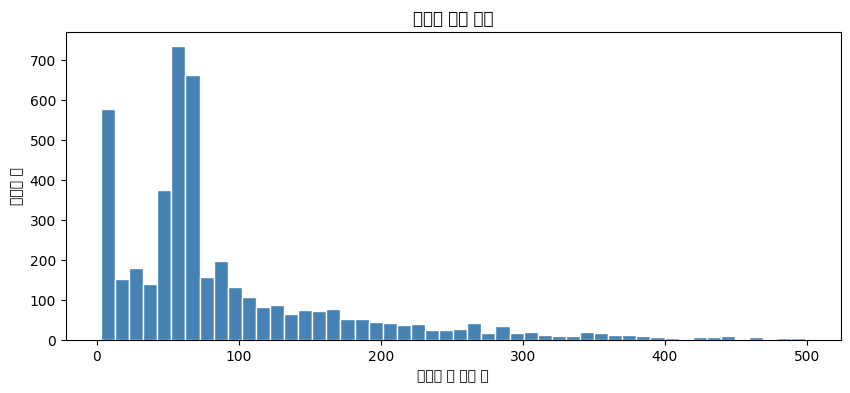


10개 이하 웹로그: 532개
10~50개 웹로그:   782개
50~100개 웹로그:  1,965개
100개 이상 웹로그: 1,216개


In [31]:
# 세션 길이 분포 확인
lengths = [len(s) for s in web_logs]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.xlabel("웹로그 내 요청 수")
plt.ylabel("웹로그 수")
plt.title("웹로그 길이 분포")
plt.show()

print(f"\n10개 이하 웹로그: {sum(1 for l in lengths if l <= 10):,}개")
print(f"10~50개 웹로그:   {sum(1 for l in lengths if 10 < l <= 50):,}개")
print(f"50~100개 웹로그:  {sum(1 for l in lengths if 50 < l <= 100):,}개")
print(f"100개 이상 웹로그: {sum(1 for l in lengths if l > 100):,}개")

**CSIC 데이터셋으로부터 공격 생성**

인공지능에게는 공격 유형 분석을 맡김

In [32]:
# POST 요청 원본 확인
with open("/content/drive/MyDrive/csic2010/anomalousTrafficTest.txt", "r", encoding="latin-1") as f:
    content = f.read()

# POST 요청 찾아서 원본 출력
lines = content.split('\n')
for i, line in enumerate(lines):
    if line.startswith("POST"):
        print(f"=== POST 요청 원본 (라인 {i}) ===")
        for j in range(i, min(i+15, len(lines))):
            print(f"{j}: {repr(lines[j])}")
        print()
        break

=== POST 요청 원본 (라인 13) ===
13: 'POST http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1'
14: 'User-Agent: Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko)'
15: 'Pragma: no-cache'
16: 'Cache-control: no-cache'
17: 'Accept: text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=0.8,image/png,*/*;q=0.5'
18: 'Accept-Encoding: x-gzip, x-deflate, gzip, deflate'
19: 'Accept-Charset: utf-8, utf-8;q=0.5, *;q=0.5'
20: 'Accept-Language: en'
21: 'Host: localhost:8080'
22: 'Cookie: JSESSIONID=AE29AEEBDE479D5E1A18B4108C8E3CE0'
23: 'Content-Type: application/x-www-form-urlencoded'
24: 'Connection: close'
25: 'Content-Length: 146'
26: ''
27: 'id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25&B1=A%F1adir+al+carrito'



In [33]:
def parse_single_request(lines):
    if not lines:
        return None
    req = {
        "method": None, "url": None, "path": None,
        "params": {}, "headers": {}, "body": None,
        "user_agent": None, "cookie": None,
        "has_cookie": False,
    }
    try:
        first_line = lines[0].strip()
        HTTP_METHODS = ["GET", "POST", "PUT", "DELETE", "HEAD", "OPTIONS"]
        if not any(first_line.startswith(m) for m in HTTP_METHODS):
            return None

        parts = first_line.split(" ")
        req["method"] = parts[0]
        req["url"]    = parts[1] if len(parts) > 1 else ""

        if "?" in req["url"]:
            req["path"] = req["url"].split("?")[0]
            for param in req["url"].split("?")[1].split("&"):
                if "=" in param:
                    k, v = param.split("=", 1)
                    req["params"][k] = v
        else:
            req["path"] = req["url"]

        # 헤더 파싱
        body_start = None
        for i, line in enumerate(lines[1:], 1):
            if line.strip() == "":
                body_start = i + 1  # 빈 줄 다음이 body
                break
            if ": " in line:
                k, v = line.split(": ", 1)
                k = k.strip().lower()
                req["headers"][k] = v.strip()
                if k == "user-agent":   req["user_agent"] = v.strip()
                elif k == "cookie":     req["cookie"] = v.strip(); req["has_cookie"] = True

        # POST body 파싱 ← 수정된 부분
        if req["method"] == "POST" and body_start is not None:
            # body_start 이후 비어있지 않은 첫 줄
            for i in range(body_start, len(lines)):
                body = lines[i].strip()
                if body:
                    req["body"] = body
                    for param in body.split("&"):
                        if "=" in param:
                            k, v = param.split("=", 1)
                            req["params"][k] = v
                    break

    except:
        return None
    return req

print("파싱 함수 수정 완료!")

파싱 함수 수정 완료!


In [34]:
def parse_requests(filepath):
    requests, current = [], []
    with open(filepath, "r", encoding="latin-1") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].rstrip('\n')

        # HTTP 메서드로 시작하는 줄 = 새 요청 시작
        HTTP_METHODS = ["GET ", "POST ", "PUT ", "DELETE ", "HEAD "]
        if any(line.startswith(m) for m in HTTP_METHODS):
            if current:
                req = parse_single_request(current)
                if req: requests.append(req)
            current = [line]
        elif current:
            current.append(line)

        i += 1

    # 마지막 요청 처리
    if current:
        req = parse_single_request(current)
        if req: requests.append(req)

    return requests

print("parse_requests 수정 완료!")

parse_requests 수정 완료!


In [35]:
# 파싱 실행
attack_requests = parse_requests(
    "/content/drive/MyDrive/csic2010/anomalousTrafficTest.txt"
)
print(f"공격 요청 수: {len(attack_requests):,}")

공격 요청 수: 25,065


In [36]:
# path 분포 확인
from collections import Counter

attack_paths = [r["path"] for r in attack_requests if r["path"]]
print("=== 공격 Path 분포 (상위 20개) ===")
for path, cnt in Counter(attack_paths).most_common(20):
    print(f"  {cnt:4d}  {path}")

=== 공격 Path 분포 (상위 20개) ===
  2821  http://localhost:8080/tienda1/publico/anadir.jsp
  2783  http://localhost:8080/tienda1/publico/autenticar.jsp
  2781  http://localhost:8080/tienda1/publico/registro.jsp
  2774  http://localhost:8080/tienda1/miembros/editar.jsp
  2722  http://localhost:8080/tienda1/publico/pagar.jsp
  1957  http://localhost:8080/tienda1/publico/caracteristicas.jsp
  1884  http://localhost:8080/tienda1/publico/vaciar.jsp
  1835  http://localhost:8080/tienda1/publico/entrar.jsp
    51  http://localhost:8080/tienda1/asf-logo-wide.gif
    51  http://localhost:8080/
    49  http://localhost:8080/tienda1/asf-logo-wide.gif/
    47  http://localhost:8080/tienda1/6909030637832563290.jsp
    46  http://localhost:8080/tienda1/asf-logo-wide
    39  http://localhost:8080/asf-logo-wide
    38  http://localhost:8080/tienda1/4861362529278789730
    38  http://localhost:8080/asf-logo-wide.gif/
    37  http://localhost:8080/asf-logo-wide.gif
    36  http://localhost:8080/48613625292787

In [37]:
# 공격 요청 샘플 확인
print("=== 공격 요청 샘플 10개 ===")
for req in attack_requests[:10]:
    print(f"\nMethod: {req['method']}")
    print(f"URL:    {req['url'][:100]}")
    print(f"Params: {req['params']}")
    print(f"Body:   {req['body']}")

=== 공격 요청 샘플 10개 ===

Method: GET
URL:    http://localhost:8080/tienda1/publico/anadir.jsp?id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%2
Params: {'id': '2', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25', 'B1': 'A%F1adir+al+carrito'}
Body:   None

Method: POST
URL:    http://localhost:8080/tienda1/publico/anadir.jsp
Params: {'id': '2', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25', 'B1': 'A%F1adir+al+carrito'}
Body:   id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25&B1=A%F1adir+al+carrito

Method: GET
URL:    http://localhost:8080/tienda1/publico/anadir.jsp?id=2%2F&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad
Params: {'id': '2%2F', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '49', 'B1': 'A%F1adir+al+carrito'}
Body:  

In [38]:
# method 분포
attack_methods = [r["method"] for r in attack_requests if r["method"]]
print("=== 공격 Method 분포 ===")
for method, cnt in Counter(attack_methods).most_common():
    print(f"  {cnt:4d}  {method}")

=== 공격 Method 분포 ===
  15088  GET
  9580  POST
   397  PUT


In [39]:
# 다시 파싱
attack_requests = parse_requests("/content/drive/MyDrive/csic2010/anomalousTrafficTest.txt")
print(f"공격 요청 수: {len(attack_requests):,}")

# POST body 확인
post_reqs = [r for r in attack_requests if r["method"] == "POST"]
print(f"POST 요청 수: {len(post_reqs):,}")
for req in post_reqs[:3]:
    print(f"\nMethod: {req['method']}")
    print(f"Path:   {req['path']}")
    print(f"Body:   {req['body']}")
    print(f"Params: {req['params']}")

공격 요청 수: 25,065
POST 요청 수: 9,580

Method: POST
Path:   http://localhost:8080/tienda1/publico/anadir.jsp
Body:   id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25&B1=A%F1adir+al+carrito
Params: {'id': '2', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25', 'B1': 'A%F1adir+al+carrito'}

Method: POST
Path:   http://localhost:8080/tienda1/publico/anadir.jsp
Body:   id=2%2F&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=49&B1=A%F1adir+al+carrito
Params: {'id': '2%2F', 'nombre': 'Jam%F3n+Ib%E9rico', 'precio': '85', 'cantidad': '49', 'B1': 'A%F1adir+al+carrito'}

Method: POST
Path:   http://localhost:8080/tienda1/publico/autenticar.jsp
Body:   modo=entrar&login=bob%40%3CSCRipt%3Ealert%28Paros%29%3C%2FscrIPT%3E.parosproxy.org&pwd=84m3ri156&remember=on&B1=Entrar
Params: {'modo': 'entrar', 'login': 'bob%40%3CSCRipt%3Ealert%28Paros%29%3C%2Fsc

In [40]:
from urllib.parse import unquote_plus
import re
from collections import Counter

# ── 키워드 정의 ──────────────────────────────────────────

SQLI_KEYWORDS = [
    "SELECT", "DROP", "INSERT", "UPDATE", "DELETE",
    "UNION", "WHERE", "FROM", "HAVING", "GROUP BY",
    "OR 1=1", "AND 1=1", "OR '1'='1",
    "' OR", "\" OR",
    "--", "/*", "*/", "#",
    "SLEEP(", "BENCHMARK(", "WAITFOR", "EXEC(",
    "CAST(", "CONVERT(", "LIKE '%",
]

XSS_KEYWORDS = [
    "<SCRIPT", "</SCRIPT>", "<IFRAME", "<IMG",
    "<SVG", "<BODY", "<INPUT",
    "ONERROR=", "ONLOAD=", "ONCLICK=", "ONMOUSEOVER=",
    "ALERT(", "CONFIRM(", "PROMPT(",
    "JAVASCRIPT:", "VBSCRIPT:",
    "%3CSCRIPT", "%3C/SCRIPT",
    "253CSCRIPT", "&#60;SCRIPT",
]

TRAVERSAL_KEYWORDS = [
    "../", "..\\",
    "%2E%2E/", "%2E%2E\\",
    "..%2F", "..%5C",
    "%252E%252E",
    "ETC/PASSWD", "ETC/SHADOW",
    "WIN.INI", "BOOT.INI", "SYSTEM32",
    "IISSAMPLES",
    "6909030637832563290",
    "4861362529278789730",
]

CRLF_KEYWORDS = [
    "%0D%0A", "%0A%0D", "%0A", "%0D",
]

ABNORMAL_METHODS = [
    "PUT", "DELETE", "OPTIONS",
    "TRACE", "CONNECT", "PATCH",
]

BRUTEFORCE_PATHS = ["autenticar", "login", "signin"]

TAMPERING_SPECIAL = [
    "%2F", "%7C", "%2B", "%7E", "%2A", "*", "~",
    "%2500", "%253F", "%2C", "%3F", "%27", "%00",
    "%25", "%3C", "%3E", "%22", "%60",
    "%28", "%29", "%3B", "%40",
]

SCANNING_REGEX = [
    r"\.gif$", r"\.htm$", r"\.bak$",
    r"\.old$", r"\.inc$", r"\.asp$",
    r"jsp/$", r"gif/$", r"jpg/$", r"css/$",
    r"~$", r"\.java$",
    r"localhost:8080http",
    r"/publico/$", r"imagenes/$", r"global/$",
]

SCANNING_PATHS = [
    "iisstart", "travelnet", "asf-logo",
    "iissamples", "phpmyadmin", "manager/",
    "9090/examples", "wp-admin", ".env", ".git",
]


# ── 보조 함수 ──────────────────────────────────────────

def is_tampering(req):
    keys     = list(req["params"].keys())
    values   = list(req["params"].values())
    all_vals = " ".join(values)

    # 파라미터 키 이름 끝에 대문자 (idA, rememberA 등)
    if any(re.search(r'[a-zA-Z0-9][A-Z]$', k) for k in keys):
        return True

    # 값에 인코딩된 특수문자 포함
    if any(s.lower() in all_vals.lower() for s in TAMPERING_SPECIAL):
        return True

    # 값이 + 만 있거나 끝에 + 붙은 경우
    for v in values:
        v = v.strip()
        if v == "+" or v.endswith("+"):
            return True

    return False


def is_scanning(req):
    p = (req["path"] or "").lower()

    # 정규식 패턴 매칭
    if any(re.search(pat, p) for pat in SCANNING_REGEX):
        return True

    # 비정상 경로 포함
    if any(s in p for s in SCANNING_PATHS):
        return True

    # 파라미터 없고 tienda1도 없는 경로
    if not req["params"] and "tienda1" not in p:
        return True

    return False


# ── 메인 분류 함수 ──────────────────────────────────────

def classify_attack(req):
    url      = unquote_plus(req["url"] or "")
    body     = unquote_plus(req["body"] or "")
    params_raw = " ".join(req["params"].values())
    path     = req["path"] or ""

    try:
        params_decoded = unquote_plus(unquote_plus(params_raw))
    except:
        params_decoded = params_raw

    all_text = (url + " " + body + " " + params_decoded).upper()

    if any(k in all_text for k in SQLI_KEYWORDS):
        return "sqli"
    elif any(k in all_text for k in XSS_KEYWORDS):
        return "xss"
    elif any(k in all_text for k in TRAVERSAL_KEYWORDS):
        return "traversal"
    elif any(k in all_text for k in CRLF_KEYWORDS):
        return "crlf"
    elif req["method"] in ABNORMAL_METHODS:
        return "abnormal_method"
    elif is_tampering(req):
        return "tampering"
    elif any(p in path for p in BRUTEFORCE_PATHS):
        return "bruteforce"
    elif is_scanning(req):
        return "scanning"
    else:
        return "other"


In [41]:
for req in attack_requests:
    req["attack_type"] = classify_attack(req)

attack_types = [r["attack_type"] for r in attack_requests]
print("=== 최종 공격 유형 분포 ===")
for attack_type, cnt in Counter(attack_types).most_common():
    print(f"  {cnt:5d}  {attack_type}")

other_reqs = [r for r in attack_requests if r["attack_type"] == "other"]
print(f"\nother 남은 수: {len(other_reqs):,}")

=== 최종 공격 유형 분포 ===
  12264  tampering
   4721  sqli
   4270  scanning
   1374  xss
   1119  traversal
    826  crlf
    397  abnormal_method
     94  bruteforce

other 남은 수: 0


In [42]:
# other 중 패턴 분석
other_reqs = [r for r in attack_requests if r["attack_type"] == "other"]

# path 분포 확인
other_paths = [r["path"] for r in other_reqs if r["path"]]
print("=== other Path 분포 (상위 20개) ===")
for path, cnt in Counter(other_paths).most_common(20):
    print(f"  {cnt:4d}  {path}")

print("\n=== other params 샘플 ===")
for req in other_reqs[:10]:
    print(f"\nPath:   {req['path']}")
    print(f"Params: {req['params']}")
    print(f"Body:   {req['body']}")

=== other Path 분포 (상위 20개) ===

=== other params 샘플 ===


In [43]:
import pickle
import os

os.makedirs("/content/drive/MyDrive/csic2010", exist_ok=True)

with open("/content/drive/MyDrive/csic2010/attack_requests.pkl", "wb") as f:
    pickle.dump(attack_requests, f)

print(f"저장 완료! 공격 요청 수: {len(attack_requests):,}")
!ls -lh /content/drive/MyDrive/csic2010/

저장 완료! 공격 요청 수: 25,065
total 294M
-rw------- 1 root root 16M May 11 07:10 anomalousTrafficTest.txt
-rw------- 1 root root 20M May 16 04:25 attack_requests.pkl
-rw------- 1 root root 94M May 11 06:11 eclog_1day.csv
-rw------- 1 root root 36M May 14 15:59 negative_pairs.pkl
-rw------- 1 root root 20M May 11 07:10 normalTrafficTest.txt
-rw------- 1 root root 20M May 11 07:10 normalTrafficTraining.txt
-rw------- 1 root root   0 May 16 04:22 positive_pairs.pkl
-rw------- 1 root root 35M May 14 15:59 sessions.pkl
-rw------- 1 root root 58M May 11 07:24 web_logs.pkl


**대조 학습을 위한 준비**

In [44]:
# 지금 메모리에 있는 것들 확인
print(f"web_logs: {len(web_logs):,}개")
print(f"attack_requests: {len(attack_requests):,}개")

web_logs: 4,495개
attack_requests: 25,065개


In [45]:
# 웹로그 -> 세션으로 만든은 함수
import uuid
import hashlib

def sessionize(web_log):
    if not web_log:
        return None

    # client_key: JSESSIONID 우선, 없으면 IP + UA 해시
    def get_client_key(row):
        cookie = str(row.get("cookie", "") or "")
        if "JSESSIONID" in cookie:
            for part in cookie.split(";"):
                if "JSESSIONID" in part:
                    return part.strip()
        ip = str(row.get("IpId", ""))
        ua = str(row.get("UserAgent", ""))
        return hashlib.md5((ip + ua).encode()).hexdigest()[:16]

    session = {
        "session_id":  str(uuid.uuid4()),
        "client_key":  get_client_key(web_log[0]),
        "requests":    []
    }

    prev_timestamp = None

    for row in web_log:
        # timestamp 변환 (이미 dt_seconds로 변환된 값 사용)
        timestamp = float(row.get("dt_seconds", 0))

        # dt 계산
        dt = 0.0
        if prev_timestamp is not None:
            dt = timestamp - prev_timestamp
        prev_timestamp = timestamp

        # cookie 정보
        cookie = str(row.get("cookie", "") or "")
        has_cookie = len(cookie) > 0

        # cookie_changed (이전 요청과 비교)
        prev_cookie = session["requests"][-1]["cookie"] if session["requests"] else None
        cookie_changed = (prev_cookie is not None and prev_cookie != cookie)

        # URL 파싱
        uri = str(row.get("Uri", "") or "")
        if "?" in uri:
            path   = uri.split("?")[0]
            params = {}
            for param in uri.split("?")[1].split("&"):
                if "=" in param:
                    k, v = param.split("=", 1)
                    params[k] = v
        else:
            path   = uri
            params = {}

        req = {
            "ip":               str(row.get("IpId", "")),
            "timestamp":        timestamp,
            "method":           str(row.get("HttpMethod", "")),
            "path":             path,
            "params":           params,
            "status":           int(row.get("ResponseCode", 0)),
            "size":             int(row.get("Bytes", 0)),
            "user_agent":       str(row.get("UserAgent", "") or ""),
            "cookie":           cookie,
            "dt":               dt,
            "has_cookie":       has_cookie,
            "cookie_changed":   cookie_changed,
        }
        session["requests"].append(req)

    return session


# web_logs → sessions 변환
sessions = []
for web_log in web_logs:
    s = sessionize(web_log)
    if s:
        sessions.append(s)

print(f"sessions 수: {len(sessions):,}")

# 샘플 확인
s = sessions[0]
print(f"\nsession_id:  {s['session_id']}")
print(f"client_key:  {s['client_key']}")
print(f"요청 수:     {len(s['requests'])}")
print(f"\n=== 첫 3개 요청 ===")
for req in s["requests"][:3]:
    print(f"  {req['method']} {req['path']} {req['status']} dt={req['dt']:.1f}s has_cookie={req['has_cookie']}")

sessions 수: 4,495

session_id:  8c0b884f-524e-4fcc-a786-9745f1feab7e
client_key:  ebe6db730c749e5d
요청 수:     60

=== 첫 3개 요청 ===
  GET /p-3388.html 200 dt=0.0s has_cookie=False
  GET /szablony/shop_11.rwd/css/style.php 200 dt=0.0s has_cookie=False
  GET /javascript/skrypty.php 200 dt=0.0s has_cookie=False


In [46]:
# 각 pair를 만들기 위한 증강
def augment_session(session, dropout_p=0.15, jitter_p=0.3, jitter_rate=0.1):
    """
    dropout_p: 각 요청이 제거될 확률 (15%)
    jitter_p:  각 요청에 jitter가 적용될 확률 (30%)
    jitter_rate: jitter 범위 (±10%)
    """
    requests = session["requests"]

    # Step 1: Request Dropout
    if len(requests) > 3:
        result = [req for req in requests if random.random() > dropout_p]
        if len(result) < 3:
            result = requests[:3]
    else:
        result = requests[:]

    # Step 2: Temporal Jitter (일부 요청에만 적용)
    result = [copy.deepcopy(req) for req in result]
    for i in range(1, len(result)):
        if random.random() < jitter_p:  # 30% 확률로만 jitter 적용
            if result[i]["dt"] > 0:
                noise = result[i]["dt"] * random.uniform(-jitter_rate, jitter_rate)
                result[i]["dt"] = max(0.0, result[i]["dt"] + noise)

    augmented = copy.deepcopy(session)
    augmented["session_id"] = str(uuid.uuid4())
    augmented["requests"]   = result
    return augmented

In [47]:
# Positive pair 만들기
def make_positive_pair(session):
  view_a = augment_session(session)
  view_b = augment_session(session)
  # NT-Xent Loss를 위함 같은 것의 두가지 버젼은 가깝게
  return view_a, view_b

print("증강 함수 정의 완료")

증강 함수 정의 완료


In [48]:
# 세션에 공격 삽입하는 메서드
import random
import copy

def inject_attack(session, attack_type=None):
    if attack_type:
        candidates = [r for r in attack_requests
                      if r["attack_type"] == attack_type]
    else:
        attack_type = random.choice([
            "sqli", "xss", "traversal", "crlf",
            "tampering", "bruteforce", "scanning", "abnormal_method"
        ])
        candidates = [r for r in attack_requests
                      if r["attack_type"] == attack_type]

    if not candidates:
        return None

    attack_req = random.choice(candidates)
    requests   = session["requests"]
    half       = len(requests) // 2
    new_requests = copy.deepcopy(requests[:half])

    for req in requests[half:]:
        new_req = copy.deepcopy(req)

        if attack_type in ["sqli", "xss", "crlf", "tampering"]:
            if attack_req["params"]:
                new_req["params"] = copy.deepcopy(attack_req["params"])

        elif attack_type == "bruteforce":
            new_req["dt"]     = random.uniform(0.1, 0.5)
            new_req["status"] = 401

        elif attack_type == "scanning":
            scan_paths = ["/admin", "/.env", "/wp-admin",
                          "/config", "/.git", "/backup.sql"]
            new_req["path"]   = random.choice(scan_paths)
            new_req["params"] = {}
            new_req["status"] = 404
            new_req["dt"]     = random.uniform(0.5, 2.0)

        elif attack_type == "traversal":
            traversal = ["/../../../etc/passwd",
                         "/%2E%2E/%2E%2E/etc/shadow",
                         "/.git/config"]
            new_req["path"]   = new_req["path"] + random.choice(traversal)
            new_req["status"] = 403

        elif attack_type == "abnormal_method":
            new_req["method"] = random.choice(["PUT", "DELETE", "OPTIONS"])
            new_req["status"] = 405

        new_requests.append(new_req)

    attacked = copy.deepcopy(session)
    attacked["session_id"]  = str(uuid.uuid4())
    attacked["requests"]    = new_requests
    attacked["attack_type"] = attack_type
    attacked["label"]       = 1

    return attacked


# 이상 세션 합성
attacked_sessions = []

for session in sessions:
    attacked = inject_attack(session)
    if attacked:
        attacked_sessions.append(attacked)

print(f"이상 세션 수: {len(attacked_sessions):,}")

# 공격 유형 분포
from collections import Counter
types = [s["attack_type"] for s in attacked_sessions]
print("\n=== 공격 유형 분포 ===")
for t, cnt in Counter(types).most_common():
    print(f"  {cnt:4d}  {t}")

# 샘플 확인
sample = attacked_sessions[0]
half   = len(sample["requests"]) // 2
print(f"\n=== 이상 세션 샘플 ({sample['attack_type']}) ===")
print(f"전체 요청 수: {len(sample['requests'])}")
print(f"\n앞 절반 (정상):")
for req in sample["requests"][:3]:
    print(f"  {req['method']} {req['path']} {req['status']}")
print(f"\n뒤 절반 (공격):")
for req in sample["requests"][half:half+3]:
    print(f"  {req['method']} {req['path']} {req['status']} params={list(req['params'].keys())}")

이상 세션 수: 4,495

=== 공격 유형 분포 ===
   618  bruteforce
   564  crlf
   563  scanning
   559  abnormal_method
   559  traversal
   550  xss
   545  tampering
   537  sqli

=== 이상 세션 샘플 (tampering) ===
전체 요청 수: 60

앞 절반 (정상):
  GET /p-3388.html 200
  GET /szablony/shop_11.rwd/css/style.php 200
  GET /javascript/skrypty.php 200

뒤 절반 (공격):
  GET /szablony/shop_11.rwd/obrazki/szablon/tlo_gradient_stopki.png 200 params=['idA']
  GET /szablony/shop_11.rwd/obrazki/szablon/cien_stopki.png 200 params=['idA']
  GET /szablony/shop_11.rwd/obrazki/szablon/stopka_info.png 200 params=['idA']


In [49]:
# Negative pair 만들기
def make_negative_pair(session):
    # 1. 공격 세션 합성
    attacked = inject_attack(session)
    if attacked is None:
        return None

    # 2. 증강 적용 (Positive pair와 동일하게)
    negative = augment_session(attacked)
    return negative

**세션화 메서드 테스트**

In [50]:
# 세션화 메서드 테스트
# 현재 상태 확인
print(f"web_logs 수: {len(web_logs):,}")
print(f"sessions 수: {len(sessions):,}")

# web_log[0] → session[0] 변환 비교
print("\n=== web_logs[0] 원본 (첫 3개 요청) ===")
for row in web_logs[0][:3]:
    print(f"  {row['HttpMethod']} {row['Uri'][:50]} {row['ResponseCode']}")

print("\n=== sessions[0] 변환 결과 (첫 3개 요청) ===")
s = sessions[0]
print(f"session_id: {s['session_id']}")
print(f"client_key: {s['client_key']}")
for req in s["requests"][:3]:
    print(f"  method={req['method']}")
    print(f"  path={req['path'][:50]}")
    print(f"  status={req['status']}")
    print(f"  dt={req['dt']:.2f}초")
    print(f"  has_cookie={req['has_cookie']}")
    print()

web_logs 수: 4,495
sessions 수: 4,495

=== web_logs[0] 원본 (첫 3개 요청) ===
  GET /p-3388.html?gclid=EAIaIQobChMIuvLUrJ-t5gIVRpZ3Ch1 200
  GET /szablony/shop_11.rwd/css/style.php?ncss=style,box 200
  GET /javascript/skrypty.php 200

=== sessions[0] 변환 결과 (첫 3개 요청) ===
session_id: 8c0b884f-524e-4fcc-a786-9745f1feab7e
client_key: ebe6db730c749e5d
  method=GET
  path=/p-3388.html
  status=200
  dt=0.00초
  has_cookie=False

  method=GET
  path=/szablony/shop_11.rwd/css/style.php
  status=200
  dt=0.00초
  has_cookie=False

  method=GET
  path=/javascript/skrypty.php
  status=200
  dt=0.00초
  has_cookie=False



In [51]:
# dt 확인
print("=== sessions[0] dt 분포 ===")
dts = [req["dt"] for req in sessions[0]["requests"]]
print(f"dt=0인 요청 수: {sum(1 for d in dts if d == 0.0)}")
print(f"dt>0인 요청 수: {sum(1 for d in dts if d > 0.0)}")
print(f"\n처음 10개 dt값:")
for i, d in enumerate(dts[:10]):
    print(f"  req{i+1}: {d:.2f}초")

=== sessions[0] dt 분포 ===
dt=0인 요청 수: 54
dt>0인 요청 수: 6

처음 10개 dt값:
  req1: 0.00초
  req2: 0.00초
  req3: 0.00초
  req4: 0.00초
  req5: 0.00초
  req6: 0.00초
  req7: 0.00초
  req8: 0.00초
  req9: 0.00초
  req10: 0.00초


In [52]:
# web_logs[0]의 타임스탬프 확인
print("=== web_logs[0] 타임스탬프 원본 ===")
for i, row in enumerate(web_logs[0][:5]):
    print(f"  req{i+1}: TimeStamp={row['TimeStamp']} dt_seconds={row.get('dt_seconds', 'None')}")

=== web_logs[0] 타임스탬프 원본 ===
  req1: TimeStamp=637116520720000000 dt_seconds=1576055272.0
  req2: TimeStamp=637116520720000000 dt_seconds=1576055272.0
  req3: TimeStamp=637116520720000000 dt_seconds=1576055272.0
  req4: TimeStamp=637116520720000000 dt_seconds=1576055272.0
  req5: TimeStamp=637116520720000000 dt_seconds=1576055272.0


In [53]:
# dt > 0인 요청 확인
print("=== dt > 0인 요청들 ===")
for i, req in enumerate(sessions[0]["requests"]):
    if req["dt"] > 0:
        print(f"  req{i+1}: dt={req['dt']:.2f}초 path={req['path'][:50]}")

=== dt > 0인 요청들 ===
  req20: dt=1.00초 path=/szablony/shop_11.rwd/obrazki/szablon/tlo_menu_nag
  req47: dt=3.00초 path=/szablony/shop_11.rwd/obrazki/kartaProduktu/zoom_z
  req48: dt=1.00초 path=/inne/informacja_online.php
  req54: dt=1.00초 path=/images/sierpien_1/image2941.jpg
  req55: dt=5.00초 path=/images/mini/70px_image316.jpg
  req59: dt=6.00초 path=/images/4_wrzesien_3/mini/70px_image1795.jpg


** 각 pair 생성**

In [54]:
# positive pair 샘플 확인
positive_pairs = []

# 1. positive pair 생성
for session in sessions:
    view_a, view_b = make_positive_pair(session)
    positive_pairs.append({
        "view_a": view_a,
        "view_b": view_b,
        "label":  0
    })

print(f"Positive pair 수: {len(positive_pairs):,}")

# 샘플 확인
pair = positive_pairs[0]
print(f"\n원본 요청 수: {len(sessions[0]['requests'])}")
print(f"뷰 A 요청 수: {len(pair['view_a']['requests'])}")
print(f"뷰 B 요청 수: {len(pair['view_b']['requests'])}")
pair = positive_pairs[0]
print(f"원본 요청 수: {len(sessions[0]['requests'])}")
print(f"뷰 A 요청 수: {len(pair['view_a']['requests'])}")
print(f"뷰 B 요청 수: {len(pair['view_b']['requests'])}")

# dt 변화 확인
print("\n=== 뷰 A dt > 0인 요청 ===")
for req in pair['view_a']['requests']:
    if req['dt'] > 0:
        print(f"  dt={req['dt']:.2f}초 path={req['path'][:40]}")

Positive pair 수: 4,495

원본 요청 수: 60
뷰 A 요청 수: 55
뷰 B 요청 수: 49
원본 요청 수: 60
뷰 A 요청 수: 55
뷰 B 요청 수: 49

=== 뷰 A dt > 0인 요청 ===
  dt=1.00초 path=/szablony/shop_11.rwd/obrazki/szablon/tl
  dt=0.92초 path=/inne/informacja_online.php
  dt=0.92초 path=/images/sierpien_1/image2941.jpg
  dt=5.00초 path=/images/mini/70px_image316.jpg
  dt=6.00초 path=/images/4_wrzesien_3/mini/70px_image1795


In [55]:
# 2. Negative pair 생성
negative_pairs = []

for session in sessions:
    neg = make_negative_pair(session)
    if neg:
        negative_pairs.append(neg)

print(f"Negative pair 수: {len(negative_pairs):,}")

# 샘플 확인
neg = negative_pairs[0]
half = len(neg["requests"]) // 2
print(f"\n공격 유형: {neg['attack_type']}")
print(f"전체 요청 수: {len(neg['requests'])}")
print(f"\n앞 절반 (정상):")
for req in neg["requests"][:3]:
    print(f"  {req['method']} {req['path'][:50]} {req['status']}")
print(f"\n뒤 절반 (공격):")
for req in neg["requests"][half:half+3]:
    print(f"  {req['method']} {req['path'][:50]} {req['status']} params={list(req['params'].keys())[:3]}")

Negative pair 수: 4,495

공격 유형: traversal
전체 요청 수: 47

앞 절반 (정상):
  GET /szablony/shop_11.rwd/css/style.php 200
  GET /javascript/skrypty.php 200
  GET /javascript/jquery.js 304

뒤 절반 (공격):
  GET /szablony/shop_11.rwd/obrazki/szablon/cien_stopki. 403 params=[]
  GET /szablony/shop_11.rwd/obrazki/szablon/stopka_info. 403 params=[]
  GET /szablony/shop_11.rwd/obrazki/moduly_stale/zamknij 403 params=[]


In [56]:
import pickle
import os

os.makedirs("/content/drive/MyDrive/csic2010", exist_ok=True)

# 정상 세션을 증강한 view_a, view_b 쌍 4495개 -> Positive pair
with open("/content/drive/MyDrive/csic2010/positive_pairs.pkl", "wb") as f:
    pickle.dump(positive_pairs, f)

# 정상 데이터에 공격 패턴 삽입 + 증강된 세션 4495개 -> Negative pair
with open("/content/drive/MyDrive/csic2010/negative_pairs.pkl", "wb") as f:
    pickle.dump(negative_pairs, f)

# 원본 정상 세션 4495개. 학습 후 추론 단계에서 정상 클러스터 중심 c 계
with open("/content/drive/MyDrive/csic2010/sessions.pkl", "wb") as f:
    pickle.dump(sessions, f)

print("저장 완료!")
!ls -lh /content/drive/MyDrive/csic2010/

저장 완료!
total 350M
-rw------- 1 root root 16M May 11 07:10 anomalousTrafficTest.txt
-rw------- 1 root root 20M May 16 04:25 attack_requests.pkl
-rw------- 1 root root 94M May 11 06:11 eclog_1day.csv
-rw------- 1 root root 36M May 16 04:27 negative_pairs.pkl
-rw------- 1 root root 20M May 11 07:10 normalTrafficTest.txt
-rw------- 1 root root 20M May 11 07:10 normalTrafficTraining.txt
-rw------- 1 root root 56M May 16 04:27 positive_pairs.pkl
-rw------- 1 root root 35M May 16 04:27 sessions.pkl
-rw------- 1 root root 58M May 11 07:24 web_logs.pkl


In [57]:
# 저장된 데이터 로드
import pickle
with open("/content/drive/MyDrive/csic2010/sessions.pkl", "rb") as f:
    sessions = pickle.load(f)

with open("/content/drive/MyDrive/csic2010/positive_pairs.pkl", "rb") as f:
    positive_pairs = pickle.load(f)

with open("/content/drive/MyDrive/csic2010/negative_pairs.pkl", "rb") as f:
    negative_pairs = pickle.load(f)

with open("/content/drive/MyDrive/csic2010/attack_requests.pkl", "rb") as f:
    attack_requests = pickle.load(f)

print(f"sessions:       {len(sessions):,}개")
print(f"positive_pairs: {len(positive_pairs):,}개")
print(f"negative_pairs: {len(negative_pairs):,}개")
print(f"attack_requests:{len(attack_requests):,}개")

sessions:       4,495개
positive_pairs: 4,495개
negative_pairs: 4,495개
attack_requests:25,065개


** 모델 정의**

In [58]:
!pip install torch -q

In [59]:
# 파일 크기 확인
!ls -lh /content/drive/MyDrive/csic2010/

total 350M
-rw------- 1 root root 16M May 11 07:10 anomalousTrafficTest.txt
-rw------- 1 root root 20M May 16 04:25 attack_requests.pkl
-rw------- 1 root root 94M May 11 06:11 eclog_1day.csv
-rw------- 1 root root 36M May 16 04:27 negative_pairs.pkl
-rw------- 1 root root 20M May 11 07:10 normalTrafficTest.txt
-rw------- 1 root root 20M May 11 07:10 normalTrafficTraining.txt
-rw------- 1 root root 56M May 16 04:27 positive_pairs.pkl
-rw------- 1 root root 35M May 16 04:27 sessions.pkl
-rw------- 1 root root 58M May 11 07:24 web_logs.pkl


In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import random

print(f"PyTorch 버전: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

PyTorch 버전: 2.10.0+cu128
GPU 사용 가능: True
사용 디바이스: cuda


In [61]:
# TF-IDF 피처 추출기 학습
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 모든 세션의 path+params를 텍스트로 변환
def req_to_text(req):
    path   = req["path"] or ""
    params = " ".join(req["params"].values()) if req["params"] else ""
    return f"{path} {params}".strip()

# 전체 텍스트 수집 (TF-IDF 학습용)
all_texts = []
for session in sessions:
    for req in session["requests"]:
        all_texts.append(req_to_text(req))

# TF-IDF 학습
tfidf = TfidfVectorizer(max_features=512, ngram_range=(1,2))
tfidf.fit(all_texts)

print(f"TF-IDF 학습 완료!")
print(f"전체 텍스트 수: {len(all_texts):,}")
print(f"어휘 크기: {len(tfidf.vocabulary_):,}")

TF-IDF 학습 완료!
전체 텍스트 수: 407,911
어휘 크기: 512


In [62]:
# 피처 추출 함수
from sklearn.preprocessing import MinMaxScaler
import torch

# One-hot 인코딩 기준
METHOD_LIST = ["GET", "POST", "PUT", "DELETE", "HEAD", "OPTIONS"]
STATUS_LIST  = ["2xx", "3xx", "4xx", "5xx", "other"]

# 상태 코드 특징 추출
def status_to_class(status):
    if 200 <= status < 300: return "2xx"
    elif 300 <= status < 400: return "3xx"
    elif 400 <= status < 500: return "4xx"
    elif 500 <= status < 600: return "5xx"
    else: return "other"

def extract_request_features(req):
    # TF-IDF (dim=512) -> request 관련
    text = req_to_text(req)
    tfidf_vec = tfidf.transform([text]).toarray()[0]

    # method One-hot (dim=6)
    method_vec = [1.0 if req["method"] == m else 0.0 for m in METHOD_LIST]

    # status One-hot (dim=5)
    status_class = status_to_class(req["status"])
    status_vec   = [1.0 if status_class == s else 0.0 for s in STATUS_LIST]

    # has_cookie One-hot (dim=1)
    cookie_vec = [1.0 if req["has_cookie"] else 0.0]

    # size 정규화 (dim=1)
    size = np.log1p(req["size"]) / 20.0

    # dt 정규화 (dim=1)
    dt = np.log1p(req["dt"]) / 10.0

    # concat → 총 dim = 512+6+5+1+1+1 = 526
    feat = np.concatenate([
        tfidf_vec,
        method_vec,
        status_vec,
        cookie_vec,
        [size],
        [dt]
    ])
    return feat.astype(np.float32)

# 테스트
sample_feat = extract_request_features(sessions[0]["requests"][0])
print(f"피처 벡터 차원: {sample_feat.shape}")

피처 벡터 차원: (526,)


In [68]:
# 세션 피처 추출 함수
  # 여기서 위에 정의한 특징 추출 함수 사용 (실제 세션 입력 시 특징 추출)
def extract_session_features(session, max_len=100):
    """
    세션 → 요청 피처 행렬
    (max_len, 526) shape으로 패딩/트런케이션
    """
    feats = []
    for req in session["requests"][:max_len]:
        feats.append(extract_request_features(req))

    # 패딩 (max_len보다 짧으면 0으로 채움)
    feat_dim = feats[0].shape[0]
    while len(feats) < max_len:
        feats.append(np.zeros(feat_dim, dtype=np.float32))

    return np.stack(feats)  # (max_len, feat_dim)

# 테스트
sample_matrix = extract_session_features(sessions[0])
print(f"세션 피처 행렬 shape: {sample_matrix.shape}")

세션 피처 행렬 shape: (100, 526)


In [69]:
# 모델 정의 (MLP + Bi-GRU)
import torch
import torch.nn as nn

# 특징 추출 -> 요청 인코더 -> 세션 인코더
class SessionEncoder(nn.Module):
    def __init__(self, feat_dim=526, mlp_hidden=256, mlp_out=128,
                 gru_hidden=128, gru_layers=2, z_dim=256):
        super().__init__()

        # 요청 인코더 (MLP)
        self.request_encoder = nn.Sequential(
            nn.Linear(feat_dim, mlp_hidden),
            nn.BatchNorm1d(mlp_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(mlp_hidden, mlp_out),
            nn.ReLU(),
        )

        # 세션 인코더 (Bi-GRU)
        self.session_encoder = nn.GRU(
            input_size=mlp_out,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2,
        )

        # 최종 세션 벡터 (Bi-GRU 출력 → z)
        self.fc = nn.Linear(gru_hidden * 2, z_dim)

    def forward(self, x):
        """
        x: (batch, seq_len, feat_dim)
        """
        batch, seq_len, feat_dim = x.shape

        # 요청 인코더: 각 요청을 MLP로 인코딩
        x = x.view(batch * seq_len, feat_dim)   # (batch*seq_len, feat_dim)
        x = self.request_encoder(x)              # (batch*seq_len, mlp_out)
        x = x.view(batch, seq_len, -1)           # (batch, seq_len, mlp_out)

        # 세션 인코더: Bi-GRU
        out, _ = self.session_encoder(x)         # (batch, seq_len, gru_hidden*2)

        # 마지막 타임스텝 + 평균 풀링 조합
        last  = out[:, -1, :]                    # (batch, gru_hidden*2)
        mean  = out.mean(dim=1)                  # (batch, gru_hidden*2)
        z     = self.fc(last + mean)             # (batch, z_dim)

        return F.normalize(z, dim=1)             # L2 정규화

# 모델 초기화
model = SessionEncoder().to(device)
print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

# 테스트
sample_input = torch.randn(4, 100, 526).to(device)
sample_output = model(sample_input)
print(f"입력 shape: {sample_input.shape}")
print(f"출력 shape: {sample_output.shape}")

모델 파라미터 수: 728,704
입력 shape: torch.Size([4, 100, 526])
출력 shape: torch.Size([4, 256])


In [70]:
# NT-Xent Loss 구현
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_pos_a, z_pos_b, z_neg):
        """
        z_pos_a: Positive pair 뷰 A (batch, z_dim)
        z_pos_b: Positive pair 뷰 B (batch, z_dim)
        z_neg:   Negative pair     (batch, z_dim)
        """
        batch = z_pos_a.shape[0]

        # 모든 벡터 concat
        # [뷰A_1, 뷰A_2, ..., 뷰B_1, 뷰B_2, ..., neg_1, neg_2, ...]
        z_all = torch.cat([z_pos_a, z_pos_b, z_neg], dim=0)  # (3*batch, z_dim)

        # 유사도 행렬
        sim = torch.mm(z_all, z_all.T) / self.temperature     # (3*batch, 3*batch)

        # 자기 자신과의 유사도 제거
        mask = torch.eye(3 * batch, device=z_all.device).bool()
        sim.masked_fill_(mask, float('-inf'))

        # Positive pair 인덱스
        # 뷰A_i의 Positive = 뷰B_i (인덱스 i + batch)
        labels = torch.arange(batch, device=z_all.device)
        labels_a = labels + batch   # 뷰A → 뷰B가 정답
        labels_b = labels           # 뷰B → 뷰A가 정답

        # Loss 계산
        loss_a = F.cross_entropy(sim[:batch], labels_a)
        loss_b = F.cross_entropy(sim[batch:2*batch], labels_b)
        loss   = (loss_a + loss_b) / 2

        return loss

criterion = NTXentLoss(temperature=0.07)
print("NT-Xent Loss 정의 완료!")

# 테스트
z_a = torch.randn(4, 256).to(device)
z_b = torch.randn(4, 256).to(device)
z_n = torch.randn(4, 256).to(device)
loss = criterion(z_a, z_b, z_n)
print(f"테스트 Loss: {loss.item():.4f}")

NT-Xent Loss 정의 완료!
테스트 Loss: 251.9574


In [71]:
# NT-Xent Loss 검증
# Positive pair가 실제로 가까울 때 Loss가 낮아지는지 확인

# 케이스 1: z_a == z_b (완전히 같을 때) → Loss 낮아야 함
z_a = F.normalize(torch.randn(8, 256), dim=1).to(device)
z_b = z_a.clone()  # 완전히 동일
z_n = F.normalize(torch.randn(8, 256), dim=1).to(device)
loss1 = criterion(z_a, z_b, z_n)
print(f"뷰A==뷰B일 때 Loss: {loss1.item():.4f}  ← 낮아야 함")

# 케이스 2: 완전 랜덤일 때 → Loss 높아야 함
z_a = F.normalize(torch.randn(8, 256), dim=1).to(device)
z_b = F.normalize(torch.randn(8, 256), dim=1).to(device)
z_n = F.normalize(torch.randn(8, 256), dim=1).to(device)
loss2 = criterion(z_a, z_b, z_n)
print(f"완전 랜덤일 때 Loss: {loss2.item():.4f}  ← 높아야 함")

print(f"\n케이스1 < 케이스2? {loss1.item() < loss2.item()}")

뷰A==뷰B일 때 Loss: 0.0000  ← 낮아야 함
완전 랜덤일 때 Loss: 3.5518  ← 높아야 함

케이스1 < 케이스2? True
